In [2]:
import os
import torch
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
# Setup
# ========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 2  # ubah sesuai jumlah class (termasuk background)

model = fasterrcnn_resnet50_fpn(pretrained=False)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
model.load_state_dict(torch.load("model_epoch_20.pth", map_location=device))
model.to(device)
model.eval()

c:\Users\acer\AppData\Local\Programs\PythonCodingPack\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\acer\AppData\Local\Programs\PythonCodingPack\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
<ipython-input-3-3da03de42b21>:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `wei

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu

Tidak terdeteksi


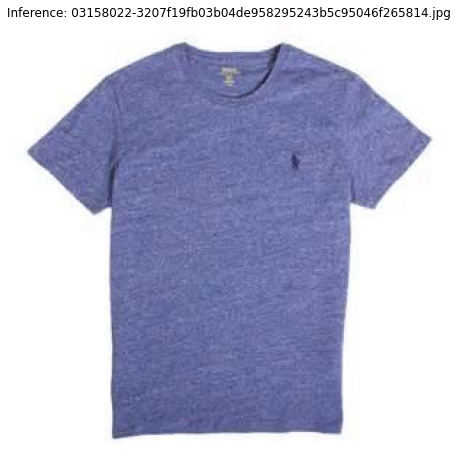

Tidak terdeteksi


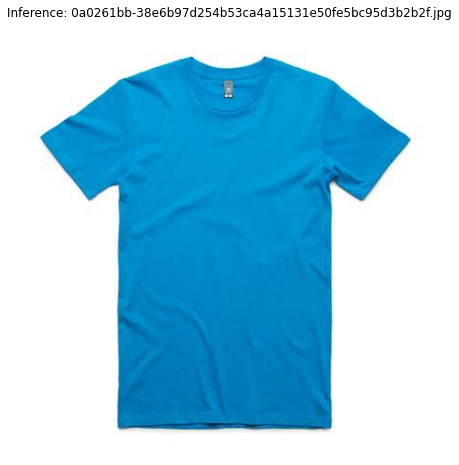

Tidak terdeteksi


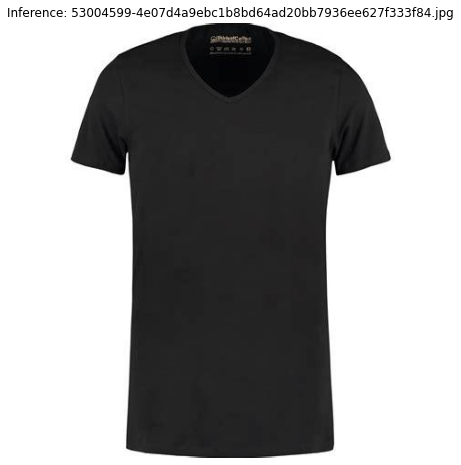

KeyboardInterrupt: 

In [9]:
# Inference ke gambar baru
# ========================
inference_dir = "dataset_pv/images_test"
image_files = [f for f in os.listdir(inference_dir) if f.endswith((".jpg", ".png"))]

for img_file in image_files:
    img_path = os.path.join(inference_dir, img_file)
    image = Image.open(img_path).convert("RGB")
    tensor = F.to_tensor(image).unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = model(tensor)[0]

    img_np = tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    boxes = prediction['boxes'].cpu().numpy()
    scores = prediction['scores'].cpu().numpy()
    labels = prediction['labels'].cpu().numpy()

    if len(prediction['boxes']) == 0:print("Tidak terdeteksi")

    # Visualisasi
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(img_np)
    for box, score, label in zip(boxes, scores, labels):
        if score > 0.01:
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                     linewidth=2, edgecolor='cyan', facecolor='none')
            ax.add_patch(rect)
            ax.text(xmin, ymin, f"Label {label}: {score:.2f}",
                    color='black', backgroundcolor='cyan', fontsize=8)
    plt.axis('off')
    plt.title(f"Inference: {img_file}")
    plt.show()